# TD9: Communicative efficiency and color naming

**NB: YOU NEED TO DOWNLOAD WCS DATA FROM HERE: https://linguistics.berkeley.edu/wcs/data.html AFTER DOWNLOADING, PUT IT IN THE WCS FOLDER.**

## 0. Question

Today, we will use the **World Color Survey (WCS)** to look at communicative efficiency in the domain of color naming. In particular, we will ask three simple questions:

1. How does one language partition the color space?
2. How can we compute listener uncertainty, or surprisal, for each color chip?
3. Do languages with more color terms tend to have lower average surprisal?

This practical is loosely inspired by [Gibson et al. (2017)](https://www.pnas.org/doi/pdf/10.1073/pnas.1619666114) and [Zaslavsky et al. (2018)](https://www.pnas.org/doi/10.1073/pnas.1800521115). As usual, we will work step by step and keep the code as transparent as possible.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set(context='notebook', style='ticks',
        font_scale=1.2, palette='colorblind')


## 1. Data

In the `WCS` folder, you will find the raw files from the World Color Survey. For the main analysis, we only need three of them:

- `term.txt`: naming responses by language, speaker, and chip
- `chip.txt`: the position of each chip in the WCS grid
- `cielab.txt`: perceptual coordinates for each chip in CIELAB space

We will also load `langs_info.txt`, so that we can keep track of language names later on.


In [3]:
BASE = 'WCS'

responses = pd.read_csv(
    f'{BASE}/term.txt',
    sep=r'\s+',
    header=None,
    names=['language_id', 'speaker_id', 'chip_id', 'response_code']
)

chips = pd.read_csv(
    f'{BASE}/chip.txt',
    sep=r'\s+',
    header=None,
    names=['chip_id', 'row', 'col', 'grid_id']
)

lab = pd.read_csv(
    f'{BASE}/cielab.txt',
    sep=r'\s+',
    header=None,
    comment='#',
    names=['chip_id', 'V', 'H', 'C', 'MunH', 'MunV', 'L_star', 'a_star', 'b_star']
)

langs = pd.read_csv(
    f'{BASE}/lang.txt',
    sep='\t',
    header=None,
    usecols=[0, 1],
    names=['language_id', 'language']
)


Let's look at the naming responses first. Each row corresponds to one naming response for one chip by one speaker.


In [4]:
responses.head(10)


,language_id,speaker_id,chip_id,response_code
0,1,1,1,LB
1,1,1,2,LB
2,1,1,3,LE
3,1,1,4,WK
4,1,1,5,LF
5,1,1,6,LE
6,1,1,7,F
7,1,1,8,LE
8,1,1,9,LE
9,1,1,10,LB


Now let's look at the chip table. This gives us the position of each chip in the WCS grid.


In [5]:
chips.head(10)


,chip_id,row,col,grid_id
0,1,E,29,E29
1,2,C,23,C23
2,3,F,4,F4
3,4,I,36,I36
4,5,C,20,C20
5,6,C,6,C6
6,7,E,15,E15
7,8,H,40,H40
8,9,G,6,G6
9,10,I,30,I30


Finally, `cielab.txt` gives the perceptual coordinates of each chip in the CIELAB color space. We will mainly use `L_star`, `a_star`, and `b_star`.


In [6]:
lab.head(10)

,chip_id,V,H,C,MunH,MunV,L_star,a_star,b_star
0,141,A,0,0,10.00RP,9.5,96.00,-0.06,0.06
1,274,B,0,0,10.00RP,9.0,91.08,-0.05,0.06
2,129,B,1,2,2.50R,9.0,91.08,5.53,2.22
3,230,B,2,2,5.00R,9.0,91.08,5.51,3.28
4,302,B,3,2,7.50R,9.0,91.08,5.54,4.46
5,324,B,4,2,10.00R,9.0,91.08,5.43,5.64
6,27,B,5,2,2.50YR,9.0,91.08,5.21,7.67
7,290,B,6,2,5.00YR,9.0,91.08,4.30,10.08
8,92,B,7,2,7.50YR,9.0,91.08,3.14,12.37
9,66,B,8,2,10.00YR,9.0,91.08,1.28,14.41


Now let's combine the response table with the chip information and the CIELAB coordinates. You should merge the tables on the `chip_id` column, and keep the relevant columns from each table (`L_star`, `a_star`, `b_star` from lab, and everything from chips and lab. You can also add language from `langs`, by joining by `language_id`.


In [7]:
# Merge the response table with the CIELAB, chip, and language tables.
# Store the result back in `responses`.
responses = responses.merge(
    lab[['chip_id', 'L_star', 'a_star', 'b_star']],
    on='chip_id',
    how='left'
).merge(
    chips,  
    on='chip_id',
    how='left'
).merge(
    langs, 
    on='language_id',
    how='left'
)

For plotting, it is convenient to convert the row column (`A`, `B`, `C`, ...) into numbers into reverse order.


In [8]:
responses['row_num'] = responses['row'].map(lambda x: ord('J') - ord(x))
responses.head(10)

,language_id,speaker_id,chip_id,response_code,L_star,a_star,b_star,row,col,grid_id,language,row_num
0,1,1,1,LB,61.70,-4.52,-39.18,E,29,E29,Abidji,5
1,1,1,2,LB,81.35,-19.64,-4.30,C,23,C23,Abidji,7
2,1,1,3,LE,51.57,55.20,68.32,F,4,F4,Abidji,4
3,1,1,4,WK,20.54,24.14,-14.33,I,36,I36,Abidji,1
4,1,1,5,LF,81.35,-33.04,4.96,C,20,C20,Abidji,7
5,1,1,6,LE,81.35,14.87,30.96,C,6,C6,Abidji,7
6,1,1,7,F,61.70,-46.97,64.65,E,15,E15,Abidji,5
7,1,1,8,LE,30.77,47.63,5.24,H,40,H40,Abidji,2
8,1,1,9,LE,41.22,22.15,41.13,G,6,G6,Abidji,3
9,1,1,10,LB,20.54,7.63,-35.92,I,30,I30,Abidji,1


Let's inspect one language first. What do you notice about how many responses each chip can receive?


In [9]:
rr = responses.query('language_id == 1').groupby('chip_id')['response_code'].value_counts()

In [10]:
rr.to_csv('donnes1.txt')

## 2. From Responses to a Partition

Each chip can receive several naming responses from different speakers. To get a simple partition of the color space for one language, we can assign each chip its **most frequent** response code. Do it using `groupby` and `agg`, combined with a lambda function that computes the most frequent response code for each chip. You can also keep the row and column information for each chip, which will be useful for plotting later on.


In [11]:
language_id = 101

language_partition = responses.query('language_id == @language_id')\
    .groupby('chip_id')\
    .agg(
        response_code = ('response_code', lambda s: s.value_counts().idxmax()),
        row_num = ('row_num', 'first'),
        col = ('col', 'first')
    ).reset_index()

language_partition

,chip_id,response_code,row_num,col
0,1,N,5,29
1,2,N,7,23
2,3,R,4,4
3,4,J,1,36
4,5,N,7,20
...,...,...,...,...
325,326,P,6,9
326,327,U,8,25
327,328,N,2,16
328,329,BR,3,7


Now plot this partition for language 10. Each square corresponds to one chip, and the color of the square shows the most frequent response code for that chip. Use seaborn's `scatteplot' function, and square markers to plot the color map.


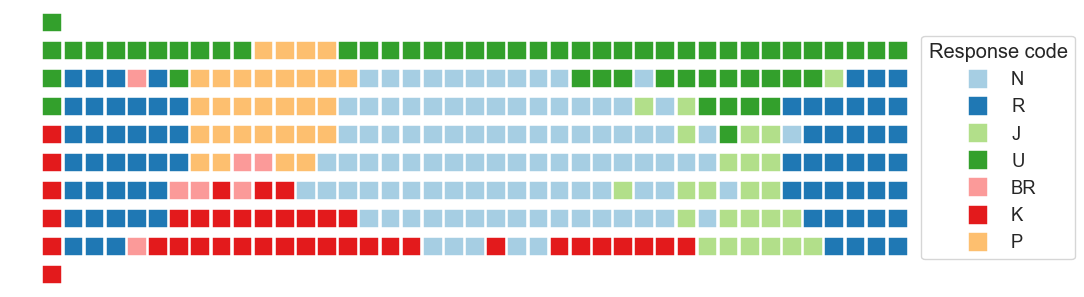

In [12]:
plt.figure(figsize=(12, 3.6))
sns.scatterplot(
    data=language_partition,
    x='col', y='row_num',
    hue='response_code',
    palette='Paired',
    s=200,
    marker='s'
)
sns.despine(left=True, bottom=True)
plt.xticks([])
plt.yticks([])
plt.xlabel('')
plt.ylabel('')
plt.legend(title='Response code', 
           bbox_to_anchor=(0.97, 0.94), loc='upper left')
plt.show()

## 3. Surprisal of Each Chip

Now we will compute listener uncertainty for each chip. We will use the following definition:

$$S(c)=\sum_w P(w\mid c)\log_2 \frac{1}{P(c\mid w)}$$

where

$$P(c\mid w)=\frac{P(w\mid c)P(c)}{P(w)}$$

Assume a uniform prior over chips within a language, so that $P(c)=1/N_c$, where $N_c$ is the number of chips.

We will first compute everything for one language and one chip, and then turn the procedure into a function. Take chip 1 in language 1 as an example. Compute $P(w\mid c)$ for each response code $w$ (so what is the probability of each word to be used with this chip, use `value_counts(normalize=True)' for this), and then compute $P(c\mid w)$ (probability of using each word across all chips) and then you can surprisal $S(c)$ for this chip.


In [13]:
language_id = 1
language_responses = responses.query('language_id == @language_id').copy()
chip_id = 198

Let's compute $P(w\mid c)$ for each word $w$ for chip 1 in language 1:

In [14]:
# Compute the distribution of response codes for this chip and language, 
# and store it in `chip_word_probs`. 
# Normalize the distribution so that it sums to 1 
# (use value_counts with `normalize=True` in `value_counts`).

chip_word_probs = language_responses.query('chip_id == @chip_id')['response_code'].\
value_counts(normalize=True)

chip_word_probs

response_code
LB    1.0
Name: proportion, dtype: float64

This gives us $P(w\mid c)$ for chip 1 in language 1. Now compute the overall probability of each word in this language, that is, $P(w)$. Use the same approach, but this time don't filter by chip id.


In [15]:
# Compute the overall probability of each response code in this language
# and store it in `word_probs`.
word_probs = language_responses['response_code'].value_counts(normalize=True)
word_probs

response_code
LB    0.239030
F     0.177455
LE    0.148485
G     0.121455
WK    0.113333
LF    0.107273
S     0.079273
FU    0.011636
GB    0.002061
Name: proportion, dtype: float64

Now we have everything we need to compute one surprisal contribution. Let's do it for one word first.


In [16]:
example_word = chip_word_probs.index[0]
p_c = 1 / 330

p_c_w = (chip_word_probs[example_word] * p_c) / word_probs[example_word]
suprisal_w1 = chip_word_probs[example_word] * np.log2(1 / p_c_w)
suprisal_w1

6.301587646603187

Now let's write a small function that computes surprisal for one chip. The function takes the responses of one language and one chip ID as input.


In [17]:
def chip_surprisal(language_responses, chip_id):
    surprisal = 0
    p_c = 1 / 330
    responses_ = language_responses.query('chip_id == @chip_id')['response_code']
    p_w_c = responses_.value_counts(normalize=True)
    p_w = language_responses['response_code'].value_counts(normalize=True)
    for word, prob in p_w_c.items():
        p_c_w = (prob * p_c) / p_w[word]
        surprisal += prob * np.log2(1 / p_c_w)
    
    return surprisal

Let's test the function on chip 1 in language 1.


In [18]:
chip_surprisal(language_responses, 1)

7.211502192466494

Now convert this into a function that computes the **average** surprisal across all chips in one language. Use the `chip_surisal' function to compute this.


In [19]:
def language_surprisal(language_id):
    language_responses_ = responses.query('language_id == @language_id')

    chip_scores = [chip_surprisal(language_responses_, chip) for chip in range(1, 331)]
    
    return np.mean(chip_scores)

Tesit it for language 1.

In [20]:
language_surprisal(4)

6.765898016979893

Now let's plot a color map for a language with surpisal instead of categories:

In [21]:
# compute surprisal for all chips of one language, and save it together
# with the chip coordinates for plotting
language_id = 5
language_responses = responses.\
    query('language_id == @language_id').\
        drop_duplicates(subset=['chip_id']).copy()
language_responses['surprisal'] = language_responses['chip_id'].apply(lambda chip_id: chip_surprisal(language_responses, chip_id))
language_responses.head()

,language_id,speaker_id,chip_id,response_code,L_star,a_star,b_star,row,col,grid_id,language,row_num,surprisal
35970,5,1,1,7,61.70,-4.52,-39.18,E,29,E29,Amarakaeri,5,6.087463
35971,5,1,2,2,81.35,-19.64,-4.30,C,23,C23,Amarakaeri,7,6.247928
35972,5,1,3,4,51.57,55.20,68.32,F,4,F4,Amarakaeri,4,5.584963
35973,5,1,4,6,20.54,24.14,-14.33,I,36,I36,Amarakaeri,1,5.523562
35974,5,1,5,7,81.35,-33.04,4.96,C,20,C20,Amarakaeri,7,6.087463


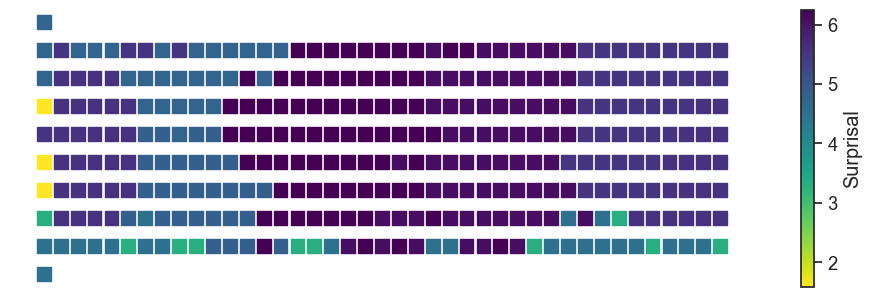

In [22]:
plot_data = language_responses

fig, ax = plt.subplots(figsize=(12, 3.6))
sc = ax.scatter(
    plot_data['col'],
    plot_data['row_num'],
    c=plot_data['surprisal'],
    cmap='viridis_r',
    s=100,
    marker='s'
)

ax.invert_yaxis()
sns.despine(left=True, bottom=True)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

fig.colorbar(sc, ax=ax, label='Surprisal')
plt.show()

Now apply this function to all languages and store the results in a dataframe together with the number of distinct response codes in each language.


In [23]:
# Build `language_scores` with one row per language, together with
# `average_surprisal`, `num_words`, and the language metadata.
language_scores = pd.DataFrame({'language_id': range(1, 111)})
language_scores['average_surprisal'] = language_scores['language_id'].\
    apply(language_surprisal)

In [24]:
num_words = responses .groupby('language_id')['response_code'].nunique()
language_scores['num_words'] = num_words.values

## 4. Compare Languages

Now let's see whether languages with more color terms tend to have lower average surprisal. First, let's compute the log number of response codes, since the number of response codes varies widely across languages.


In [25]:
language_scores['log_num_words'] = np.log(language_scores['num_words'])
language_scores.head()

,language_id,average_surprisal,num_words,log_num_words
0,1,7.129926,9,2.197225
1,2,6.627612,28,3.332205
2,3,6.552551,71,4.262680
3,4,6.765898,25,3.218876
4,5,6.347536,9,2.197225


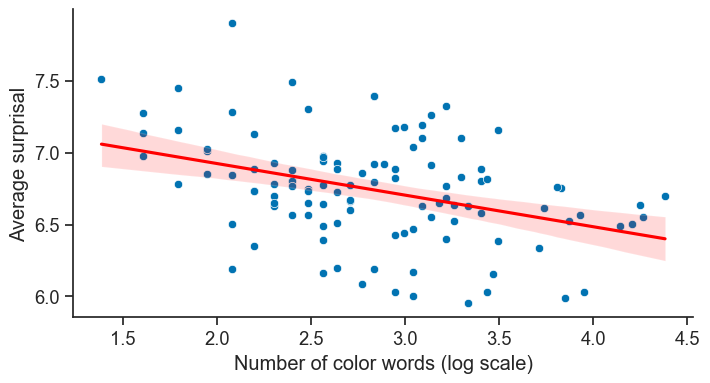

In [26]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=language_scores, x='log_num_words', y='average_surprisal')
sns.regplot(data=language_scores, x='log_num_words', y='average_surprisal', scatter=False, color='red')
plt.xlabel('Number of color words (log scale)')
plt.ylabel('Average surprisal')
sns.despine()
plt.show()


Compute the correlation between log number of response codes and average surprisal across languages. Use the Spearman correlation -- `stats.spearmanr`.

In [27]:
# Compute the Spearman correlation between `log_num_words` and
# `average_surprisal`.
correlation, p_value = stats.spearmanr(language_scores['log_num_words'], language_scores['average_surprisal'])
print(f'Correlation: {correlation:.2f}, p-value: {p_value:.4f}')

Correlation: -0.37, p-value: 0.0001


What does this analysis suggest? Is the relationship clearly linear, or do you see a lot of variation among languages with similar numbers of terms?


## 5. Additional Analysis

As a simple extension, let's compare darker and lighter chips. We will split the chips into two groups using the median value of `L_star` (which is equal to 50). Then we will compute the average surprisal for each group in each language.

We'll modify our surprisal function first to accept subsets of chips.


In [31]:
def language_surprisal_s(language_id, chips_subset=None):
    language_responses = responses.query('language_id == @language_id').copy()

    if chips_subset is None:
        chip_ids = sorted(language_responses['chip_id'].unique())
    else:
        chip_ids = sorted(set(language_responses['chip_id']).intersection(chips_subset))

    chip_scores = [chip_surprisal(language_responses, chip_id) for chip_id in chip_ids]
    return np.mean(chip_scores)

Now we can compute the average surprisal for darker and lighter chips in each language. 

In [32]:
median_l = lab['L_star'].median()
dark_chips = set(lab.loc[lab['L_star'] < median_l, 'chip_id'])
light_chips = set(lab.loc[lab['L_star'] >= median_l, 'chip_id'])

light_dark_scores = []

# Compute surprisal scores for both subsets of chips. Append a tuple
# (language_id, type (light/dark), average_surprisal) to `light_dark_scores`.
for language_id in sorted(responses['language_id'].unique()):
    light_dark_scores.append((language_id, 'dark', language_surprisal_s(language_id, dark_chips)))
    light_dark_scores.append((language_id, 'light', language_surprisal_s(language_id, light_chips)))

light_dark_scores = pd.DataFrame(light_dark_scores, columns=['language_id', 'chip_type', 'average_surprisal'])
light_dark_scores = light_dark_scores.merge(langs, on='language_id', how='left')
light_dark_scores.head()

,language_id,chip_type,average_surprisal,language
0,1,dark,7.106322,Abidji
1,1,light,7.153530,Abidji
2,2,dark,6.698886,Agarabi
3,2,light,6.556339,Agarabi
4,3,dark,6.605389,Casiguran Agta


Now let's plot this. Use `sns.pointplot` and `hue='language_id'` to match languages by light/dark surpisal.

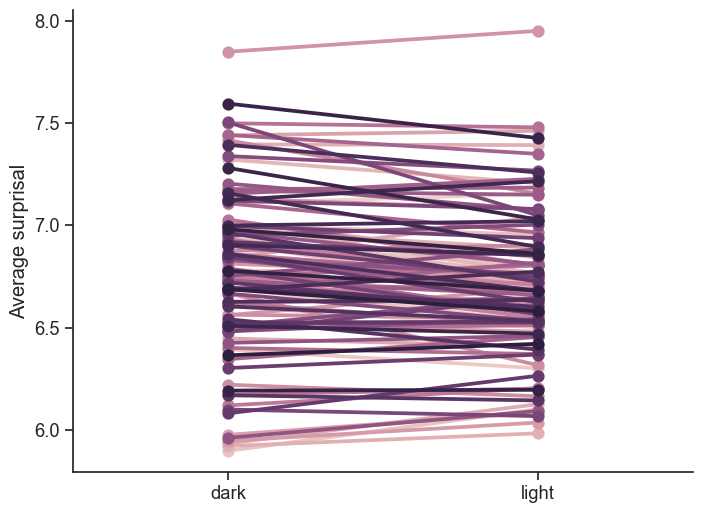

In [33]:
plt.figure(figsize=(8, 6))

sns.pointplot(
    data=light_dark_scores,
    x='chip_type',
    y='average_surprisal',
    hue='language_id',
    legend=False,
)

plt.xlabel('')
plt.ylabel('Average surprisal')
sns.despine()
plt.show()

Now let's do a paired t-test to see whether the difference between light and dark chips is significant across languages. Don't forget to sort by language ID before doing the test, so that the order of languages is the same in both groups. Use `stats.ttest_rel` for this.

In [34]:
from scipy.stats import ttest_rel

dark_scores = light_dark_scores.query('chip_type == "dark"').sort_values('language_id')['average_surprisal']
light_scores = light_dark_scores.query('chip_type == "light"').sort_values('language_id')['average_surprisal']

t_statistic, p_value = ttest_rel(dark_scores, light_scores)
print(f'T-statistic: {t_statistic:.2f}, p-value: {p_value:.4f}')


T-statistic: 4.60, p-value: 0.0000


What does this analysis suggest? Do languages tend to have higher surprisal for light or dark chips? Is the difference significant across languages?